In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import r2_score
import seaborn as sns

In [93]:
df = pd.read_csv('loan.csv')
df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


In [94]:
df = df.drop(columns='loan_id')

In [95]:
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [96]:
df.columns = df.columns.str.strip()

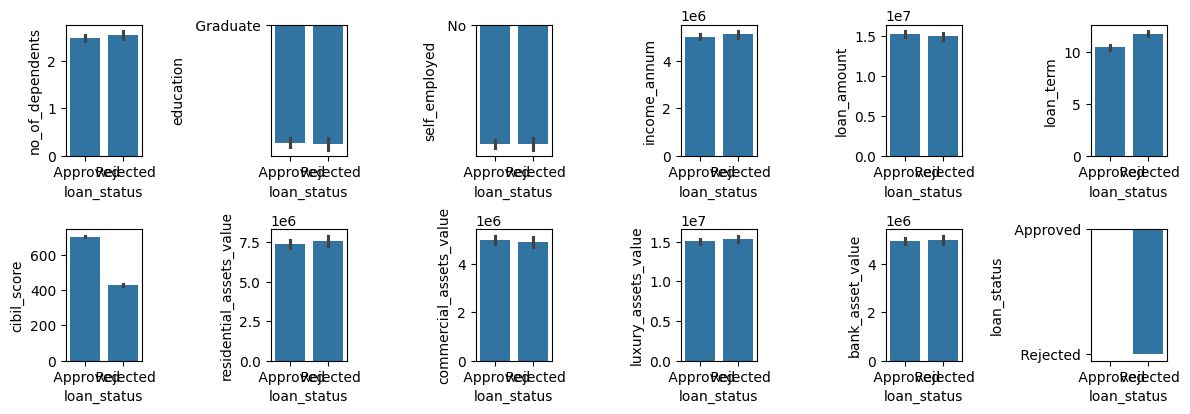

In [97]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,12))
count = 1
for col in df:
    plt.subplot(6,6,count)
    sns.barplot(data = df,x='loan_status',y=col)
    plt.tight_layout()
    count += 1


<Axes: >

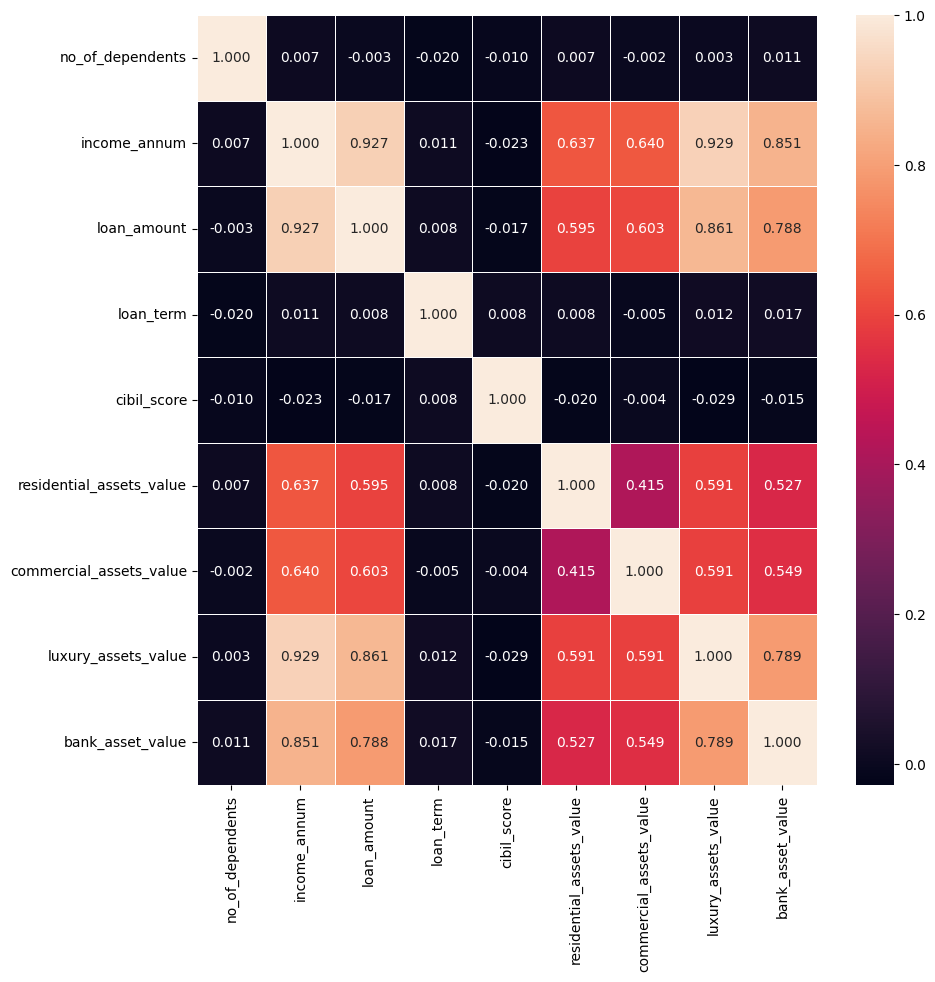

In [98]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.3f',linewidths=.5)

In [99]:
df['education'] = df['education'].astype(str).str.strip()
df['self_employed'] = df['self_employed'].astype(str).str.strip()
df['loan_status'] = df['loan_status'].astype(str).str.strip()
df['education'] = df['education'].map({'Graduate':1,'Not Graduate':0})
df['self_employed'] = df['self_employed'].map({'Yes':1,'No':0})
df['loan_status'] = df['loan_status'].map({'Approved':1,'Rejected':0})
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [100]:
x= df.drop(columns='loan_status')
y= df['loan_status']

In [102]:
scaler = StandardScaler()
x = scaler.fit_transform(x)
x

array([[-0.2941017 ,  0.99555917, -1.00728821, ...,  2.877289  ,
         0.83202837,  0.93030441],
       [-1.4735476 , -1.00446064,  0.99276452, ..., -0.63192107,
        -0.69499321, -0.51593638],
       [ 0.29562125,  0.99555917, -1.00728821, ..., -0.10781827,
         1.99651964,  2.40731629],
       ...,
       [-0.2941017 , -1.00446064, -1.00728821, ...,  1.69236092,
         0.3266831 ,  0.71490685],
       [-0.88382465, -1.00446064, -1.00728821, ..., -0.97372725,
        -0.11274758,  0.25334064],
       [-0.88382465,  0.99555917, -1.00728821, ...,  1.55563845,
         2.26017804,  2.16114764]], shape=(4269, 11))

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=.25,random_state=42)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42)
}